### Misc functions


In [3]:
def plot_traj(sol, number_of_variables, hide_legends = False):
    import matplotlib.pyplot as plt
    plt.grid(True)
    plt.title('Spin variables')
    for i, spin_var in enumerate(sol.y[0:number_of_variables]):
        x = sol.t
        y = spin_var
        plt.plot(x, y, label='s'+str(i+1))
    if not hide_legends:
        plt.legend()
    plt.show()

def plot_array(myArray):
    import matplotlib.pyplot as plt
    plt.grid(True)
    plt.title('Spin variables')
    plt.plot(myArray, label='s'+str(i+1))
    plt.legend()
    plt.show()

def plot_aux(sol, number_of_variables, hide_legends = False):
    import matplotlib.pyplot as plt
    plt.grid(True)
    plt.title('Aux variables')
    for i, spin_var in enumerate(sol.y[number_of_variables:]):
        x = sol.t
        y = spin_var
        plt.plot(x, y, label='s'+str(i+1))
    if not hide_legends:
        plt.legend()
    plt.show()

def save_plot_traj(sol, number_of_variables, file_name):
    import matplotlib.pyplot as plt
    plt.grid(True)
    plt.title('Spin variables')
    for i, spin_var in enumerate(sol.y[0:number_of_variables]):
        x = sol.t
        y = spin_var
        plt.plot(x, y, label='s'+str(i+1))
    plt.legend()
    plt.savefig(file_name+ '.png', dpi=350)

def plot_error_effect(data_dict, max_time = 1000, number_of_points = 100, hide_legends = False):
    import matplotlib.pyplot as plt
    import numpy as np
    plt.grid(True)
    plt.title('Effect of absolute tolerance')
    plt.xlabel('Analog time')
    plt.ylabel('Ratio of the unfinished init, conds')
    plt.yscale('log')
    times = np.linspace(0.0, max_time, number_of_points)
    for key, vals in data_dict.items():
        ratios = [len([elem for elem in vals if elem > t])/len(vals) for t in times]
        plt.plot(times, ratios, label=str(key))
    if not hide_legends:
        plt.legend()
    plt.show()

def save_error_effect(data_dict, file_name, max_time = 1000, number_of_points = 100, hide_legends = False):
    import matplotlib.pyplot as plt
    import numpy as np
    plt.grid(True)
    plt.title('Effect of absolute tolerance')
    plt.xlabel('Analog time')
    plt.ylabel('Ratio of the unfinished init. ,conds')
    plt.yscale('log')
    times = np.linspace(0.0, max_time, number_of_points)
    for key, vals in data_dict.items():
        ratios = [len([elem for elem in vals if elem > t])/len(vals) for t in times]
        plt.plot(times, ratios, label=str(key))
    if not hide_legends:
        plt.legend()
    plt.savefig(file_name+ '.png', dpi=350)

def average_maxAux(problem, nbr_points=100):
    results = []
    N = problem.number_of_variables
    for i in range(nbr_points):
        init_s =  2*np.random.rand(N) - np.ones(N)
        solver = CTD(problem, initial_s=init_s, random_aux=False)
        solver.fast_solve(t_max=500, solver_type='BDF', exit_type=ORTANT)
        results.append(max(solver.sol.y[N:,-1]))

    return sum(results)/nbr_points       

## General testing

### Problem instance

In [5]:
from pySAT import SAT, CTD, RHS_TYPE_EIGHT, ORTANT, HYPER_SPHERE
import numpy as np

so_file_name = 'c_libs/cSat.so'
#so_file_name = None
myProblem = SAT('SAT_problems/benchmark4.256/random3SATn40M171.cnf', so_file_name, rhs_type=8, lmbd=0.4)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses


#init_s = 2*np.random.rand(N) - np.ones(N)

solver = CTD(myProblem, initial_s=init_s, random_aux=False)
solver.fast_solve(t_max=15, solver_type='RK45', exit_type=None)

plot_aux(solver.sol, N, True)
plot_traj(solver.sol, N, True)

Lambda is 30


KeyboardInterrupt: 

Lambda is 300


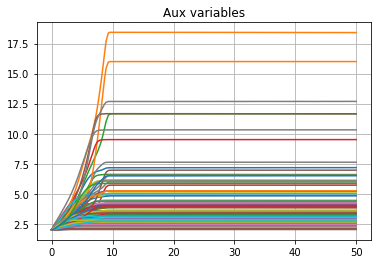

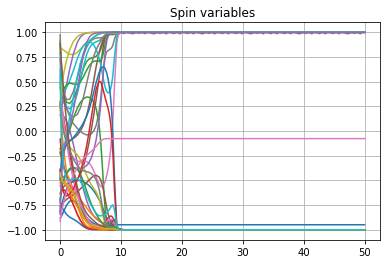

In [8]:
from pySAT import SAT, CTD, RHS_TYPE_EIGHT, ORTANT, HYPER_SPHERE
import numpy as np

so_file_name = 'c_libs/cSat.so'
myProblem = SAT('SAT_problems/benchmark4.256/random3SATn40M171.cnf', so_file_name, rhs_type=8, lmbd=300)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses


init_s = 2*np.random.rand(N) - np.ones(N)

solver = CTD(myProblem, initial_s=init_s, random_aux=False, initial_aux=2*np.ones(M))
solver.fast_solve(t_max=50, solver_type='RK45', exit_type=None)

plot_aux(solver.sol, N, True)
plot_traj(solver.sol, N, True)

In [4]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, ORTANT, HYPER_SPHERE
import numpy as np

so_file_name = 'c_libs/cSat.so'
#myProblem = SAT(None, so_file_name, rhs_type=RHS_TYPE_THREE, n = 15)
myProblem = SAT('SAT_problems/benchmark_maxaux/random3SATn19M81S4.cnf', so_file_name, rhs_type=RHS_TYPE_THREE)
#myProblem = SAT('SAT_problems/benchmark_maxaux/random3SATn15M64S3.cnf', so_file_name, rhs_type=RHS_TYPE_THREE)
#myProblem = SAT('SAT_problems/benchmark_maxaux/random3SATn16M69S5.cnf', so_file_name, rhs_type=RHS_TYPE_THREE)
myProblem = SAT('SAT_problems/5SAT/unif-p12-k5-r21.117-v250-c5279-S1173863765273039011.cnf', so_file_name, rhs_type=RHS_TYPE_THREE)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses

#print(myProblem.all_solutions())

In [5]:
import matplotlib.pyplot as plt

init_s =  2*np.random.rand(N) - np.ones(N)

solver = CTD(myProblem, initial_s=init_s, random_aux=False)
solver.fast_solve(t_max=5, solver_type='RK45', exit_type=None)

print("Max aux:{0}".format(max(solver.sol.y[N:,-1])))
with plt.style.context('ggplot'):#'seaborn-darkgrid'):
    plt.grid(True)
    plt.title('Spin variables')
    for i, spin_var in enumerate(solver.sol.y[0:N]):
        x = solver.sol.t
        y = spin_var
        plt.plot(x, y, label='s'+str(i+1))
        # plt.savefig('exmple_spin'+ '.png', dpi=350)

    # plt.title('Aux variables')
    # for i, spin_var in enumerate(solver.sol.y[N:]):
    #     x = solver.sol.t
    #     y = spin_var
    #     plt.plot(x, y, label='s'+str(i+1))
    #     plt.savefig('exmple_aux'+ '.png', dpi=350)

KeyboardInterrupt: 

In [52]:
set_of_visited_ortants = []
for i in range(len(solver.sol.y[0])):
    ortant_idx = 0
    #str_sol = ""
    for j, elem in enumerate([spin_var_series[i] for spin_var_series in solver.sol.y[0:N]]):
        if elem > 0:
            ortant_idx += 2**j
        #     str_sol += '1'
        # else:
        #     str_sol += '0'
    set_of_visited_ortants.append(ortant_idx)

print(len(set_of_visited_ortants))
print(set_of_visited_ortants)



31
[126480048028094746333367695536262481335026662141291678521792839453298398567, 126480048028094746333367695536262481335026662141291678521792843850271167847, 126480048028094746333367695536262481335026662141291678521792843850271167843, 126480048028094746333367695536262486779544532876307018377922836844239132131, 126480048028094746333367695536262660961539399897537895932195356726786528739, 126480048027686584070173802491927061616908441674064073325175901584901019107, 126480048027480795566497761664548995520738947097727471185218049281685493219, 126480048027480795958625058183613882339480625325598226917964048904864962019, 119413091127513933050528582761539748257080035544678627504615374139892996075, 6327977235350545393408611563141764040440643089429479000186399266844489707, 6327977235337689889054539640937428343701913786133421297665376374363830251, 6327977235334476012966021660386431531881047674053045930005270766293661675, 6327977235334476012966021660386431531881047674053045930581731518597085163, 632

In [54]:
no_follow = False
idx_of_to_be_removed = 2
while not no_follow:
    for i, elem in enumerate(set_of_visited_ortants):
        if i == 0:
            idx_of_to_be_removed = -1
        elif i>0 and i < len(set_of_visited_ortants)-1:
            if elem == set_of_visited_ortants[i-1]:
                idx_of_to_be_removed = i
                break
        elif i == len(set_of_visited_ortants)-1:
            print("Exit condition reached")
            no_follow = True
            idx_of_to_be_removed = -1
            break
    
    if idx_of_to_be_removed > 0:
        set_of_visited_ortants.remove(set_of_visited_ortants[idx_of_to_be_removed])

print(len(set_of_visited_ortants))
print(len(set(set_of_visited_ortants)))
#print(set_of_visited_ortants)

Exit condition reached
29
29


Max aux:311.72624640711547
14031
Exit condition reached
485
484


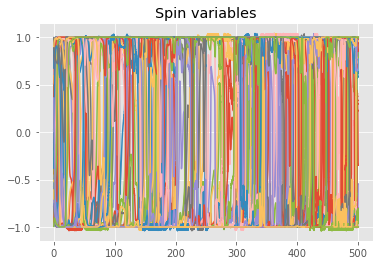

In [59]:
myProblem = SAT('SAT_problems/benchmark4.256/random3SATn90M384.cnf', so_file_name, rhs_type=RHS_TYPE_THREE)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses
init_s =  2*np.random.rand(N) - np.ones(N)

solver = CTD(myProblem, initial_s=init_s, random_aux=False)
solver.fast_solve(t_max=500, solver_type='RK23', exit_type=None)

print("Max aux:{0}".format(max(solver.sol.y[N:,-1])))
with plt.style.context('ggplot'):#'seaborn-darkgrid'):
    plt.grid(True)
    plt.title('Spin variables')
    for i, spin_var in enumerate(solver.sol.y[0:N]):
        x = solver.sol.t
        y = spin_var
        plt.plot(x, y, label='s'+str(i+1))

set_of_visited_ortants = []
for i in range(len(solver.sol.y[0])):
    ortant_idx = 0
    #str_sol = ""
    for j, elem in enumerate([spin_var_series[i] for spin_var_series in solver.sol.y[0:N]]):
        if elem > 0:
            ortant_idx += 2**j
        #     str_sol += '1'
        # else:
        #     str_sol += '0'
    set_of_visited_ortants.append(ortant_idx)

print(len(set_of_visited_ortants))
#print(set_of_visited_ortants)

no_follow = False
idx_of_to_be_removed = 2
while not no_follow:
    for i, elem in enumerate(set_of_visited_ortants):
        if i == 0:
            idx_of_to_be_removed = -1
        elif i>0 and i < len(set_of_visited_ortants)-1:
            if elem == set_of_visited_ortants[i-1]:
                idx_of_to_be_removed = i
                break
        elif i == len(set_of_visited_ortants)-1:
            print("Exit condition reached")
            no_follow = True
            idx_of_to_be_removed = -1
            break
    
    if idx_of_to_be_removed > 0:
        set_of_visited_ortants.remove(set_of_visited_ortants[idx_of_to_be_removed])

print(len(set_of_visited_ortants))
print(len(set(set_of_visited_ortants)))



In [61]:
484/14031



0.034495046682346236

### Problem generation

In [ ]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, ORTANT
import numpy as np

so_file_name = 'c_libs/cSat.so'

for alpha in np.linspace(2, 6, 100):
    myProblem = None
    exit_loop = False
    while(not exit_loop):
        myProblem = SAT(None, so_file_name, n=20, alpha=alpha, rhs_type=RHS_TYPE_THREE)
        print('Number of solutions {0}'.format(len(myProblem.all_solutions())))
        if len(myProblem.all_solutions()) >= 1:
            exit_loop = True
    N, M = myProblem.number_of_variables, myProblem.number_of_clauses
    myProblem.write_problem_to_file('SAT_problems\\benchmark20\\random3SATn'+str(N)+'M'+str(M)+'S'+str(len(myProblem.all_solutions())))


In [2]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, ORTANT
import numpy as np

so_file_name = 'c_libs/cSat.so'

myProblem = None
exit_loop = False
target_maxAux = 30#1/(2.5*0.02-0.01)#=25
while(not exit_loop):
    myProblem = SAT(None, so_file_name, n=20, alpha=3.6, rhs_type=RHS_TYPE_THREE)
    print('Number of solutions {0}'.format(len(myProblem.all_solutions())))
    if len(myProblem.all_solutions()) >= 3 and len(myProblem.all_solutions()) <= 6:
        print('Number of clusters {0}'.format(len(myProblem.get_clusters())))
        if len(myProblem.get_clusters()) >= 3:
            ave = average_maxAux(myProblem, 50)
            print("Average max aux {0}".format(ave))
            if ave >= target_maxAux:
                exit_loop = True

Number of solutions 0
Number of solutions 1
Number of solutions 0
Number of solutions 1
Number of solutions 9
Number of solutions 3
Number of clusters 1
Number of solutions 2
Number of solutions 0
Number of solutions 7
Number of solutions 20
Number of solutions 2
Number of solutions 0
Number of solutions 16
Number of solutions 17
Number of solutions 9
Number of solutions 3
Number of clusters 1
Number of solutions 13
Number of solutions 2
Number of solutions 2
Number of solutions 20
Number of solutions 6
Number of clusters 2
Number of solutions 28
Number of solutions 0
Number of solutions 0
Number of solutions 17
Number of solutions 0
Number of solutions 0
Number of solutions 1
Number of solutions 10
Number of solutions 0
Number of solutions 0
Number of solutions 18
Number of solutions 0
Number of solutions 1
Number of solutions 22
Number of solutions 0
Number of solutions 4
Number of clusters 1
Number of solutions 3
Number of clusters 1
Number of solutions 4
Number of clusters 2
Number

KeyboardInterrupt: 

In [2]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, ORTANT
import numpy as np


alpha = 4.256

for N in range(10, 100):
    myProblem = SAT(None, so_file_name, n=N, alpha=alpha, rhs_type=RHS_TYPE_THREE)
    N, M = myProblem.number_of_variables, myProblem.number_of_clauses
    myProblem.write_problem_to_file('SAT_problems\\benchmark4.256\\random3SATn'+str(N)+'M'+str(M))


In [1]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, ORTANT
import numpy as np

so_file_name = 'c_libs/cSat.so'

myProblem = SAT(None, so_file_name, n=250, alpha = 3.6, rhs_type=RHS_TYPE_THREE)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses

In [2]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, ORTANT
import numpy as np

so_file_name = 'c_libs/cSat.so'
N, M = myProblem.number_of_variables, myProblem.number_of_clauses
init_s =  2*np.random.rand(N) - np.ones(N)

solver = CTD(myProblem, initial_s=init_s, random_aux=False)
solver.fast_solve(t_max=250, solver_type='BDF', exit_type=ORTANT)

print("Max aux:{0}".format(max(solver.sol.y[N:,-1])))
plot_traj(solver.sol, myProblem.number_of_variables, True)
plot_aux(solver.sol, N, True)

#myProblem.write_problem_to_file('SAT_problems\\random3SATn'+str(N)+'M'+str(M)+'S'+str(len(myProblem.all_solutions())))

### Egyéb


In [ ]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, RHS_TYPE_ONE, RHS_TYPE_TWO, ORTANT
import numpy as np

so_file_name = 'c_libs/cSat.so'
solution_time = 0.0
while solution_time < 110.0:
    nbr_cluster = 0
    myProblem = None
    while(not (nbr_cluster == 3 or nbr_cluster == 4)):
        myProblem = SAT(None, so_file_name, n=13, alpha=4.77, rhs_type = RHS_TYPE_THREE)
        nbr_cluster = len(myProblem.get_clusters())
        nbr_sol = len(myProblem.all_solutions())
    N, M = myProblem.number_of_variables, myProblem.number_of_clauses
    init_s = [0.5846424456892467, 0.28855730591917617, -0.765485967168831, -0.19757191008885022, 0.07115735554663072, 0.8756276995661012, 0.6118210887924771, 0.5940679228111643, -0.33385990029898327,
            -0.6428940799260097, -0.053791272109619204, -0.7058511794075033, 0.5527736842134574, -0.8782685890278985, 0.29380377582167916, -0.8888067203337626, -0.4154169832230892, 0.17095162610908043,
            0.2573696988413323, -0.13771668086566802, -0.8328769256466353, -0.23920763628682162, -0.8275018021573082, -0.7581165958321621, 0.0735767709459334, 0.5068227819503663, -0.5123524411832288,
            -0.5013787551546678, -0.9948890032728812, -0.6047441113799457, 0.6911652631178293, -0.2190930534199227, -0.7662485185524224, 0.4084055267483786, -0.6192982256437018, -0.18542284167545775,
            0.43799359902439416, -0.8178673956450011, 0.017592254409698693, 0.882608207989791]
    init_s = init_s[0:N]
    solver = CTD(myProblem, initial_s=init_s, random_aux=False)
    solver.fast_solve(t_max=400, solver_type='BDF', exit_type=ORTANT)
    solution_time = solver.sol.t[-1]
    print('Solution time {0}'.format(solution_time))
plot_traj(solver.sol, myProblem.number_of_variables, hide_legends=True )
print('Number of solutions {0}, with alpha {1}'.format(nbr_sol, myProblem.get_alpha()))
print('Clusters: {0}'.format(myProblem.get_clusters()))

In [ ]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, RHS_TYPE_ONE, RHS_TYPE_TWO, ORTANT
import numpy as np
from random import random

so_file_name = 'c_libs/cSat.so'

#myProblem = SAT("random3SATn20a4.57.cnf", so_file_name, rhs_type = RHS_TYPE_TWO)
myProblem = SAT(None, so_file_name, n=26, alpha=4.3, rhs_type = RHS_TYPE_TWO)
myProblem.remove_variable(myProblem.smallest_variable())
N, M = myProblem.number_of_variables, myProblem.number_of_clauses

absolute_tolerances = [10e-8, 10e-7, 10e-6, 10e-5, 10e-4]
maxt = 150
datas = {}

for a_toll in absolute_tolerances:
    sol_times = []
    for point_idx in range(75):
        rand_init = np.array([random() for i in range(N)])
        solver = CTD(myProblem, initial_s=rand_init, random_aux=False)
        solver.fast_solve(t_max=maxt, solver_type='RK45', exit_type=ORTANT, atol=a_toll)
        if solver.solution_time is not None:
            sol_times.append(solver.solution_time)
        else:
            sol_times.append(maxt)
    datas[a_toll] = sol_times

plot_error_effect(datas, max_time=maxt, number_of_points=50)   

In [82]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, RHS_TYPE_ONE, RHS_TYPE_TWO, ORTANT, CONVERGENCE_RADIUS
import numpy as np

location = 'C:\\Users\\vizke\\AppData\\Local\\Packages\\CanonicalGroupLimited.UbuntuonWindows_79rhkp1fndgsc\\LocalState\\rootfs\home\\aron\miniSAT\\'
so_file_name = 'c_libs/cSat.so'
prob_file_name = 'random3SATn20a4.26.cnf'

#myProblem2 = SAT(location + prob_file_name, so_file_name, rhs_type = RHS_TYPE_THREE)
myProblem2 = SAT(None, so_file_name, n=45, rhs_type = RHS_TYPE_THREE)
N, M = myProblem2.number_of_variables, myProblem2.number_of_clauses

myProblem2.write_problem_to_file(location + 'random3SATn45a' + str(myProblem2.get_alpha()))
print(myProblem2.get_alpha())
#print(myProblem2.all_solutions())

4.266666666666667


In [ ]:
init_s = 2 * np.random.rand(N) - np.ones(N)
solver2 = CTD(myProblem2, initial_s=init_s, random_aux=False)
solver2.fast_solve(t_max=750, solver_type='RK45', exit_type=ORTANT)
# print(myProblem2.get_alpha())
plot_traj(solver2.sol, N, True)
# print(myProblem2.all_solutions())

In [ ]:
#myProblem2.write_problem_to_file(location + 'random3SATn'+str(N)+'a'+str(myProblem2.get_alpha()))
myProblem.write_problem_to_file('random3SATn'+str(N)+'a'+str(myProblem.get_alpha()))

In [ ]:
import numpy as np

#clusters = myProblem2.get_clusters()

ortants = ['start']
for pnt_idx in range(len(solver2.sol.y[0])):
    r_point = np.zeros(N)
    bit_string = ''
    for var_idx in range(len(solver2.sol.y)):
        if var_idx < N:
            r_point[var_idx] = solver2.sol.y[var_idx][pnt_idx]
    
    for coord in r_point:
        if coord >= 0.0:
            bit_string += '1'
        else:
            bit_string += '0'
    
    if ortants[-1] != bit_string:
        ortants.append(bit_string)
ortants.remove('start')

print(ortants)

# with open(prob_file_name + '.csv', 'w') as csv_file:
#     csv_file.write('Ortant,Cluster,Solution,\n')
#     for ortant in ortants:
#         sol_idx = 0
#         ortant_idx = 0
#         for keys, vals in clusters.items():
#             if ortant in vals:
#                 ortant_idx = keys + 1
#                 sol_idx = myProblem.get_solution_index(ortant)
#         csv_file.write("'"+ ortant +"'"+  ',' + str(ortant_idx) + ',' + str(sol_idx) + ',\n')

    

In [ ]:
dicts= [ {1: 4937, 2: 142, 3: 24, 4: 1}, {1: 7051, 2: 139, 3: 4}, {1: 12344, 2: 591, 3: 121, 4: 1}, {1: 24141, 3: 408, 4: 144, 2: 2041, 7: 24, 5: 24} ]

list_names = {'a=3.9', 'a=4.24', 'a=4.4', 'a=4.9'}

In [ ]:
myProblem3 = SAT('C:\Projects\cppSAT\pySat\SAT_problems\\random3SATn20a4.35.cnf', so_file_name, rhs_type = RHS_TYPE_THREE)
myProblem3.all_solutions()

In [ ]:
from matplotlib import pyplot as plt

ortant_set = set(ortants)

xs1 = [int(element, 2) for element in ortant_set if not myProblem2.check_solution([True if x == '1' else False for x in element])]
ys1 = [ortants.count(elem) for elem in ortant_set if not myProblem2.check_solution([True if x == '1' else False for x in elem])]
xs2 = [int(element, 2) for element in ortant_set if myProblem2.check_solution([True if x == '1' else False for x in element])]
ys2 = [ortants.count(elem) for elem in ortant_set if myProblem2.check_solution([True if x == '1' else False for x in elem])]

#plt.plot(to_plot, 'r+')
plt.plot(xs1, ys1, 'bx')
plt.plot(xs2, ys2, 'r+')
plt.grid(True)
plt.title('Histogram of analog trajectory for problem with n=40')
plt.ylabel('Multiplicity of ortant')
plt.xlabel('Decimal number of ortant')
plt.show()

In [ ]:
from pySAT import SAT, CTD
import numpy as np
from scipy import optimize

from pySAT import SAT, CTD
import numpy as np

cnf_file = "C:\Projects\cppSAT\pySat\SAT_problems\shubha_small_2.cnf"
cnf_file = "C:\Projects\cppSAT\pySat\SAT_problems\\tiny.cnf"
so_file_name = 'c_libs/cSat.so'
myProblem = SAT(cnf_file, so_file_name, rhs_type=1)
def wrapper_fnc(x, i):
    return myProblem.rhs(0, x)[i]


N, M = myProblem.number_of_variables, myProblem.number_of_clauses
u0 = np.ones(N+M)
init_s = [0.3934262373, 0.7150070725, 0.7482993410, 0.8682550782, 0.3400653559, 0.8864542655, 0.4565491083, 0.2409856937, 0.3712098457, 0.9783567466, 0.6103133947, 0.9705718923, 0.3622861688, 0.5380535901, 0.05820786103, 0.1242846544, 0.4328300679, 0.7575798495, 0.8292365090, 0.6228237150]
init_s = init_s[0:N]
u0[0:N] = np.array(init_s)
eps = np.sqrt(np.finfo(float).eps)

print("dy/dt: {0}".format(myProblem.rhs(0.0, u0)))
J = [[] for i in range(N+M)]
for i in range(N+M):
    J[i] = optimize.approx_fprime(u0, wrapper_fnc, [eps for k in range(N+M)], i)
print("Approximate Jacobian: {0}".format(J))
print("c-calculated Jakobian: {0}".format(myProblem.Jakobian(u0)))


In [ ]:

l= [bin(x)[2:].rjust(3, '0') for x in range(2**3)]
[True if kar == '1' else False for kar in l[3]]


In [ ]:
from pySAT import SAT
import numpy as np
import matplotlib.pyplot as plt

#myProblem = SAT('chaotic_SAT/8770.903495788574random3SATn13c59.cnf')
#myProblem = SAT('chaotic_SAT/small1.cnf')
myProblem = SAT('SAT_problems/shubha_small_2.cnf', None)

img_size = 1024

run_times = np.array([[0.0 for j in range(img_size)] for i in range(img_size)])
solutions = np.array([[0 for j in range(img_size)] for i in range(img_size)])

file_name = '_shubha2_sat1_zoom.out'

with open('results/'+ str(img_size) + file_name, 'r') as resultfile:
    lines = resultfile.readlines()
    l_1 = 'Loading python/3.7.3\n'
    l_2 = '  Loading requirement: tcl/8.6.8 gcc/8.3.0\n'
    while(l_1 in lines):
        lines.remove(l_1)
    while(l_2 in lines):
        lines.remove(l_2)
    for k in range(int(len(lines)/3)):
        i = int(lines[k*3].split(' ')[1])
        j = int(lines[k*3].split(' ')[3])
        sol = lines[k*3+1].split(' ')[1].replace('\n', '')
        t = float(lines[k*3+2].split(' ')[1])
        
        try:
            sol_nbr = myProblem.all_solutions().index(sol)
        except Exception as err:
            #print(err)
            sol_nbr = len(myProblem.all_solutions())
        solutions[i][j] = sol_nbr
        run_times[i, j] = np.log(t+1)

#Normalizing values
maximum = max([max(x) for x in run_times])
for i, row in enumerate(run_times):
    for j, elem in enumerate(row):
        run_times[i, j] /= maximum

print(myProblem.number_of_clauses)
plt.xlabel("s1")
plt.ylabel('s2')
plt.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom = False, labelleft = False)
# plt.imshow(run_times, cmap='Blues', resample=False)
# plt.savefig('results/basin_boundaries/'+ str(img_size) + file_name + 'logtime.png', dpi=700)
plt.imshow(solutions, cmap='Accent', interpolation='nearest')
#plt.savefig('results/basin_boundaries/'+ str(img_size) + file_name + 'boundary.png', dpi=700)

    

In [ ]:
myProblem = SAT('chaotic_SAT/shubha_small_2.cnf')

img_size = 512

run_times = []
solutions = []

file_name = '_shubha2_sat1_4.out'

with open('results/'+ str(img_size) + file_name, 'r') as resultfile:
    lines = resultfile.readlines()
    l_1 = 'Loading python/3.7.3\n'
    l_2 = '  Loading requirement: tcl/8.6.8 gcc/8.3.0\n'
    while(l_1 in lines):
        lines.remove(l_1)
    while(l_2 in lines):
        lines.remove(l_2)
    for k in range(int(len(lines)/3)):
        i = int(lines[k*3].split(' ')[1])
        j = int(lines[k*3].split(' ')[3])
        t = float(lines[k*3+2].split(' ')[1])
        

        run_times.append(t)
        solutions.append((i,j))

s1s = np.linspace(-0.9999, 0.9999, img_size)
tmax = max(run_times)
print(tmax)
(mi, mj) = solutions[run_times.index(tmax)]
print((mi, mj))
print((s1s[mi], s1s[mj]))

In [ ]:
def basin_entropy(matrix, grid_resolution = 5, number_of_solutions = None):
    img_size = len(matrix)
    N = 0
    Si = []
    if not number_of_solutions:
        number_of_solutions = max([max(row) for row in matrix])
    for i in range(img_size):
        for j in range(img_size):
            if i % grid_resolution == 0 and j % grid_resolution == 0:
                N += 1
                ps = np.zeros(number_of_solutions)
                for k in range(grid_resolution):
                    for l in range(grid_resolution):
                        ps[ matrix[i-k][j-l]-1 ] += 1
                ps = [elem / grid_resolution**2 for elem in ps ]
                Si.append(sum([pij*np.log(1/pij) if pij != 0 else 0 for pij in ps]))

    return sum(Si)/N

def basin_boundary_entropy(matrix, grid_resolution = 5, number_of_solutions = None):
    img_size = len(matrix)
    N = 0
    Si = []
    if not number_of_solutions:
        number_of_solutions = max([max(row) for row in matrix])
    for i in range(img_size):
        for j in range(img_size):
            if i % grid_resolution == 0 and j % grid_resolution == 0:
                ps = np.zeros(number_of_solutions)
                for k in range(grid_resolution):
                    for l in range(grid_resolution):
                        ps[ matrix[i-k][j-l]-1 ] += 1
                number_of_colors = sum([1 if elem > 0 else 0 for elem in ps])
                if number_of_colors > 1:
                    N += 1
                ps = [elem / grid_resolution**2 for elem in ps ]
                Si.append(sum([pij*np.log(1/pij) if pij != 0 else 0 for pij in ps]))

    return sum(Si)/N

print(np.log(2))
print(basin_boundary_entropy(solutions))
                    

### Calculating the escape rate (kappa)

In [13]:
from pySAT import SAT, CTD, RHS_TYPE_ONE, ORTANT, HYPER_SPHERE
import numpy as np

so_file_name = 'c_libs/cSat.so'
myProblem = SAT('SAT_problems/benchmark4.256/random3SATn60M256.cnf', so_file_name, rhs_type=RHS_TYPE_ONE)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses

In [14]:
number_of_initial_points = 50
initial_points = [2*np.random.rand(N) - np.ones(N) for i in range(number_of_initial_points)]

In [15]:
escape_times = [] # List of touples, first element is the time of first escape last element is the time of last escape
max_aux_values = [] # List of touples, first element is the maximum aux at the time of first escape last element is the same at time of last escape
solver = None
for init_point in initial_points:
    solver = CTD(myProblem, initial_s=init_point, random_aux=False)
    solver.fast_solve(t_max=200, solver_type='RK45', exit_type=HYPER_SPHERE, hypersphere_radius=np.sqrt(N)*0.95)
    escape_times.append( (solver.sol.t_events[0][0], solver.sol.t_events[0][-1]) )
    max_aux_values.append( (max(solver.sol.y_events[0][0]), max(solver.sol.y_events[0][-1])) )
#print(escape_times)
#print(max_aux_values)

KeyboardInterrupt: 

In [ ]:
xs_kappa_1 = np.linspace(min([elem[0] for elem in escape_times]), max([elem[0] for elem in escape_times]))
# List of the number of elements greater then t for each t in xs
ys_kappa_1 = [len([element for element in [elem[0] for elem in escape_times] if element > t])/number_of_initial_points for t in xs_kappa_1]

xs_kappa_2 = np.linspace(min([elem[1] for elem in escape_times]), max([elem[1] for elem in escape_times]))
# List of the number of elements greater then t for each t in xs
ys_kappa_2 = [len([element for element in [elem[1] for elem in escape_times] if element > t])/number_of_initial_points for t in xs_kappa_2]

# Fitting exponential decay
kappa_1, const_1 = np.polyfit(xs_kappa_1[:-1], np.log(ys_kappa_1[:-1]), 1, w=np.sqrt(ys_kappa_1[:-1]))
kappa_2, const_2 = np.polyfit(xs_kappa_2[:-1], np.log(ys_kappa_2[:-1]), 1, w=np.sqrt(ys_kappa_2[:-1]))

print(kappa_2)

-0.20039568484044146


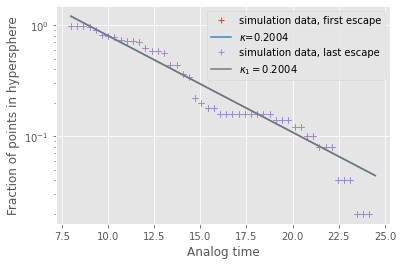

In [ ]:
import matplotlib.pyplot as plt

with plt.style.context('ggplot'):#'seaborn-darkgrid'):
    #plt.grid(True)
    #plt.title('Escaped rate with average aux_max {:.4f}'.format(sum(max_aux_values)/len(max_aux_values)))
    plt.plot(xs_kappa_1, ys_kappa_1, '+', label="simulation data, first escape")#, first escape")
    plt.plot(xs_kappa_1, [np.exp(const_1+kappa_1*element) for element in xs_kappa_1], label="$\kappa$={:.4f}".format(-kappa_1))
    plt.plot(xs_kappa_2, ys_kappa_2, '+', label="simulation data, last escape")
    plt.plot(xs_kappa_2, [np.exp(const_2+kappa_2*element) for element in xs_kappa_2], label="$\kappa_1 =${:.4f}".format(-kappa_2))
    plt.xlabel("Analog time")
    plt.yscale("log")
    plt.ylabel("Fraction of points in hypersphere")
    #plt.yscale("log")
    plt.legend()
    plt.plot()
    #plt.savefig('kappa_1_loglin.png', dpi=350)

### Calculating fraction of solved trajectories in time (p)

In [11]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, ORTANT, HYPER_SPHERE
import numpy as np

solution_times = []
max_aux_values2 = []
for init_point in initial_points:
    solver = CTD(myProblem, initial_s=init_point, random_aux=False)
    solver.fast_solve(t_max=75, solver_type='RK45', exit_type=ORTANT)
    solution_times.append(solver.sol.t[-1])
    max_aux_values2.append(max(solver.sol.y[-1]))

In [12]:
xs_p = np.linspace(min(solution_times), max(solution_times), 100)
# List of the number of elements greater then t for each t in xs
ys_p = [len([element for element in solution_times if element > t])/number_of_initial_points for t in xs_p]

# Fitting exponential decay
B, A = np.polyfit(xs_p[:-1], np.log(ys_p[:-1]), 1, w=np.sqrt(ys_p[:-1]))
print(A, B)

0.14250314700749042 -0.06002881028981493


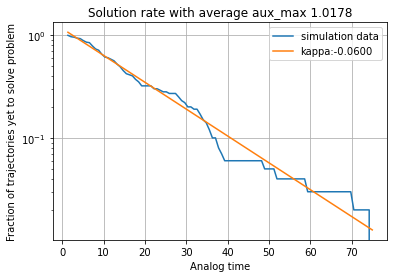

In [13]:
import matplotlib.pyplot as plt
plt.grid(True)
plt.title('Solution rate with average aux_max {:.4f}'.format(sum(max_aux_values)/len(max_aux_values)))
plt.plot(xs_p, ys_p, label="simulation data")
plt.plot(xs_p, [np.exp(A+B*element) for element in xs_p], label="kappa:{:.4f}".format(B))
plt.xlabel("Analog time")
plt.ylabel("Fraction of trajectories yet to solve problem")
plt.yscale("log")
plt.legend()

In [14]:
print(solution_times)
print(escape_times)

[13.962371183428397, 2.9243811910516873, 11.036187758682983, 8.787307345822677, 21.670886170866854, 7.278218168995664, 8.774730454106102, 13.30166322690155, 19.14055824845012, 5.18798378323074, 1.3905579704536295, 33.68884539046261, 1.5343585433294662, 29.683531158907876, 38.20104068631529, 9.478538836854373, 7.247823866203234, 37.4745304432843, 34.08128126794838, 28.276980755889344, 9.952503944067727, 23.01872114708339, 7.2923737970562055, 10.153133215712502, 38.740838742051, 12.725611195772693, 48.62769440839734, 28.588758573412917, 14.509157495713858, 29.28126232872381, 70.0892858089714, 9.764161110573417, 18.496463915003634, 14.095457234865309, 11.860002457940718, 5.467725518008669, 14.433637712911333, 15.935238486641506, 3.66752129365808, 7.927525074756736, 37.33622360376257, 1.85052575231901, 4.647068057665297, 28.141376756224865, 32.87793253719468, 34.730608876850944, 25.624271181569508, 2.733956905957197, 75.0, 5.3431315289189, 36.240327387561706, 16.60875856825323, 75.0, 7.626

### Random initial points with infinitesimal separation

In [ ]:
from pySAT import SAT, CTD, RHS_TYPE_THREE, RHS_TYPE_FIVE, ORTANT, NEGATIVE_AUX
import numpy as np
from random import random

def normalized_random_vec(dimension):
    result = 2*np.random.rand(dimension)-np.ones(dimension)
    result /= np.linalg.norm(result)
    return result

so_file_name = 'c_libs/cSat.so'
myProblem = SAT("SAT_problems\\random3SATn15a4.266666666666667.cnf", so_file_name, rhs_type=RHS_TYPE_THREE)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses

dem_deltas = np.logspace(-17, -2, 11, endpoint=True, base=10)
number_of_random_pairs = 10

p_values = []

for delta_0 in dem_deltas:
    init_as = [np.array([2*random()-1 for i in range(N)]) for j in range(number_of_random_pairs)]
    init_bs = [init + normalized_random_vec(N) * delta_0 for init in init_as]
    same_solution = 0
    different_solution = 0

    for init_a, init_b in zip(init_as, init_bs):
        solver_a = CTD(myProblem, initial_s=init_a, random_aux=False)
        solver_b = CTD(myProblem, initial_s=init_b, random_aux=False)
        solver_a.fast_solve(t_max=500, solver_type='RK45', exit_type=ORTANT)
        solver_b.fast_solve(t_max=500, solver_type='RK45', exit_type=ORTANT)
        if solver_a.get_solution() != solver_b.get_solution():
            different_solution += 1
        else:
            same_solution += 1

    p_values.append(same_solution / (same_solution + different_solution))




In [ ]:
import matplotlib.pyplot as plt
plt.grid(True)
plt.title('Spin variables')

dem_deltas = np.logspace(-17, -2, 11, endpoint=True, base=10)
p_values = np.random.rand(len(dem_deltas))
plt.xscale("log")
plt.xlabel("Initial condition separation (log scale)")
plt.ylabel("Fraction of trajectories going into the same solution")
plt.plot(dem_deltas, p_values)
plt.show()

## Exponential memory supression 

### Accuracy tests

In [1]:
from pySAT import SAT, CTD, RHS_TYPE_EIGHT, ORTANT, HYPER_SPHERE
import numpy as np

so_file_name = 'c_libs/cSat.so'
myProblem1 = SAT('SAT_problems/random3SATn15a4.266666666666667.cnf', so_file_name, rhs_type=8)
myProblem2 = SAT('SAT_problems/random3SATn15a4.266666666666667.cnf', None, rhs_type=8)
N, M = myProblem1.number_of_variables, myProblem2.number_of_clauses


init_s = 2*np.random.rand(N) - np.ones(N)
init_a = np.ones(M)

step = myProblem1.rhs(0, np.concatenate((init_s, init_a), axis=None))-myProblem2.rhs(0, np.concatenate((init_s, init_a), axis=None))

print(sum(step[0:N]))

-1.942890293094024e-16


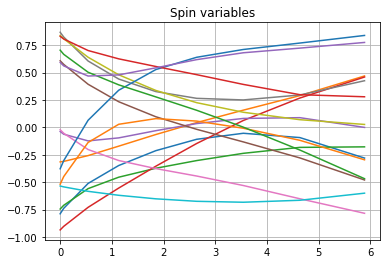

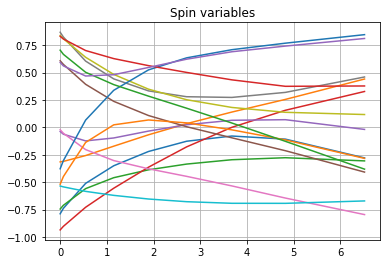

In [4]:
solver1 = CTD(myProblem1, initial_s=init_s, random_aux=False)
solver1.fast_solve(t_max=50, solver_type='RK45', exit_type=ORTANT)

solver2 = CTD(myProblem2, initial_s=init_s, random_aux=False)
solver2.fast_solve(t_max=50, solver_type='RK45', exit_type=ORTANT)

plot_traj(solver1.sol, N, True)
plot_traj(solver2.sol, N, True)

### Optimal lambda search

In [26]:
# Tabu search

def tabu_search(objective_function, getNeighbours, stopping_condition, initial_param_value = 0.0, max_tabu_size = 100):
    """Finds the maximum of the objective function"""
    local_best_candidate = initial_param_value
    seen_best_candidate = initial_param_value
    tabu_list = []
    tabu_list.append(local_best_candidate)
    while(not stopping_condition(objective_function, seen_best_candidate)):
        neighbours = getNeighbours(objective_function, local_best_candidate)
        for candidate in neighbours:
            if not candidate in tabu_list and objective_function(candidate) > objective_function(local_best_candidate):
                local_best_candidate = candidate
            if objective_function(local_best_candidate) > objective_function(seen_best_candidate):
                seen_best_candidate = local_best_candidate
            tabu_list.append(local_best_candidate)
            if len(tabu_list) > max_tabu_size:
                tabu_list.pop(0)

    return local_best_candidate

def getNeig1D(func, param, resolution = 0.01):
    return [param + resolution, param - resolution]


In [28]:
def stopSin(func, value):
    if func(value) > 0.99999:
        return True
    else :
        return False
obj_fnc = lambda x : (-x *x -6*x)/9
tabu_search(obj_fnc, getNeig1D, stopSin)

-2.99999999999998

In [5]:
print(np.linspace(-0.5, 0.0, 20))

[0.         0.02631579 0.05263158 0.07894737 0.10526316 0.13157895
 0.15789474 0.18421053 0.21052632 0.23684211 0.26315789 0.28947368
 0.31578947 0.34210526 0.36842105 0.39473684 0.42105263 0.44736842
 0.47368421 0.5       ]


In [32]:
from pySAT import SAT, CTD, RHS_TYPE_EIGHT, ORTANT, HYPER_SPHERE
import numpy as np

so_file_name = 'c_libs/cSat.so'
myProblem = SAT('SAT_problems/random3SATn15a4.266666666666667.cnf', so_file_name, rhs_type=RHS_TYPE_EIGHT)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses

inits = [2*np.random.rand(N) - np.ones(N) for i in range(75)]
results = []
lambdas = np.linspace(0.0, 0.5, 20)
for lambda_candidate in lambdas:
    total_TTS = 0.0
    
    myProblem.lmdb = lambda_candidate
    for init in inits:
        solver = CTD(myProblem, initial_s=init, random_aux=False)
        solver.fast_solve(t_max=100, solver_type='LSODA', exit_type=ORTANT)
        total_TTS += solver.get_sol_time()
    average_time = total_TTS/len(inits)
    print("Simulation with lambda {0} finished, with total time {1}".format(myProblem.lmdb, average_time))
    results.append(average_time)

Simulation with lambda 0.0 finished, with total time 27.566334709774242
Simulation with lambda 0.02631578947368421 finished, with total time 24.639001346166097
Simulation with lambda 0.05263157894736842 finished, with total time 24.639001346166097
Simulation with lambda 0.07894736842105263 finished, with total time 27.566334709774242
Simulation with lambda 0.10526315789473684 finished, with total time 24.639001346166097
Simulation with lambda 0.13157894736842105 finished, with total time 27.565829364419095
Simulation with lambda 0.15789473684210525 finished, with total time 27.566334709774242
Simulation with lambda 0.18421052631578946 finished, with total time 0.0


c:\ProgramData\Anaconda3\lib\site-packages\scipy\integrate\_ode.py:1352: UserWarning: lsoda: Repeated convergence failures (perhaps bad Jacobian or tolerances).
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


Simulation with lambda 0.21052631578947367 finished, with total time 24.639001346166097
Simulation with lambda 0.23684210526315788 finished, with total time 27.566334709774242
Simulation with lambda 0.2631578947368421 finished, with total time 27.565829364419095
Simulation with lambda 0.2894736842105263 finished, with total time 27.56471139079307
Simulation with lambda 0.3157894736842105 finished, with total time 27.566334709774242
Simulation with lambda 0.3421052631578947 finished, with total time 0.006610789467775936


c:\ProgramData\Anaconda3\lib\site-packages\scipy\integrate\_ode.py:1352: UserWarning: lsoda: Excess accuracy requested (tolerances too small).
  warnings.warn('{:s}: {:s}'.format(self.__class__.__name__,


Simulation with lambda 0.3684210526315789 finished, with total time 0.0
Simulation with lambda 0.39473684210526316 finished, with total time 1.549378465593462
Simulation with lambda 0.42105263157894735 finished, with total time 24.639001346166097
Simulation with lambda 0.4473684210526315 finished, with total time 27.566145894505937
Simulation with lambda 0.47368421052631576 finished, with total time 27.566334709774242
Simulation with lambda 0.5 finished, with total time 27.566334709774242


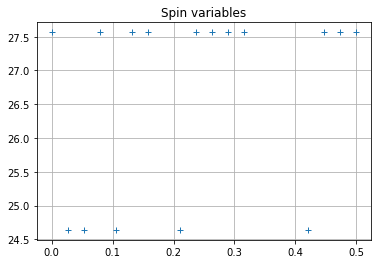

In [47]:
import matplotlib.pyplot as plt

lambdas_to_be_plotted = []
aTTS_to_be_plotted = []

for i, elem in enumerate(results):
    if elem > 5.0:
        lambdas_to_be_plotted.append(lambdas[i])
        aTTS_to_be_plotted.append(elem)

plt.grid(True)
plt.title('Spin variables')
plt.plot(lambdas_to_be_plotted, aTTS_to_be_plotted, '+')
plt.show()

In [48]:
from pySAT import SAT, CTD, RHS_TYPE_EIGHT, ORTANT, HYPER_SPHERE
import numpy as np

init_idx = 3

so_file_name = 'c_libs/cSat.so'
myProblem1 = SAT('SAT_problems/random3SATn15a4.266666666666667.cnf', so_file_name, rhs_type=RHS_TYPE_EIGHT)
myProblem2 = SAT('SAT_problems/random3SATn15a4.266666666666667.cnf', so_file_name, rhs_type=RHS_TYPE_EIGHT)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses
myProblem1.lmdb = 0.47368421052631576
myProblem2.lmdb = 0.07894736842105263

solver1 = CTD(myProblem1, initial_s=inits[init_idx], random_aux=False)
solver1.fast_solve(t_max=100, solver_type='LSODA', exit_type=ORTANT)
solver2 = CTD(myProblem1, initial_s=inits[init_idx], random_aux=False)
solver2.fast_solve(t_max=100, solver_type='LSODA', exit_type=ORTANT)

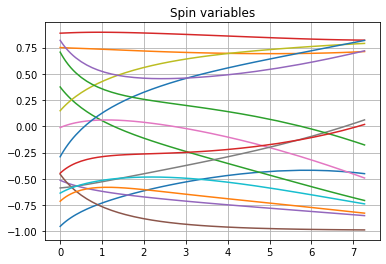

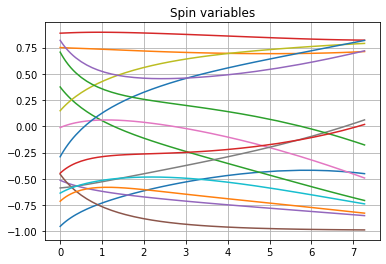

In [49]:
plot_traj(solver1.sol, N, True)
plot_traj(solver2.sol, N, True)

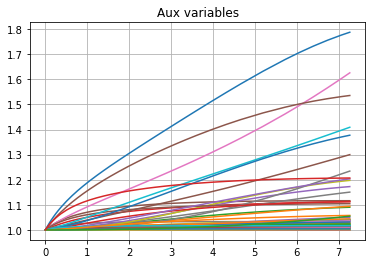

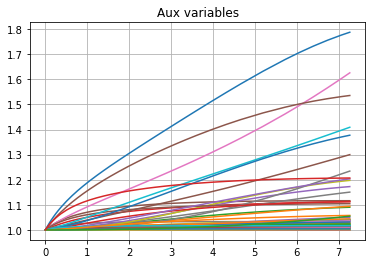

In [50]:
plot_aux(solver1.sol, N, True)
plot_aux(solver2.sol, N, True)

In [5]:
from pySAT import SAT, CTD, RHS_TYPE_SEVEN, ORTANT, HYPER_SPHERE
import numpy as np

init_idx = 3

so_file_name = None# 'c_libs/cSat.so'
myProblem = SAT('SAT_problems/random3SATn15a4.266666666666667.cnf', so_file_name, rhs_type=RHS_TYPE_SEVEN)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses
myProblem.lmdb = 0.47368421052631576

solver = CTD(myProblem, initial_s=2*np.random.rand(N) - np.ones(N), random_aux=False, initial_aux=np.zeros(M))
solver.fast_solve(t_max=50, solver_type='LSODA', exit_type=ORTANT)


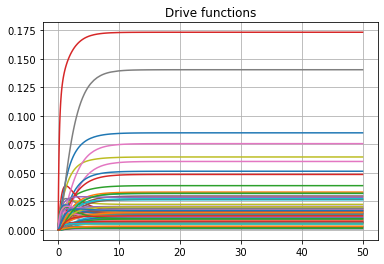

In [8]:
import matplotlib.pyplot as plt
plt.grid(True)
plt.title('Drive functions')
for i, aux_var in enumerate(solver.sol.y[N:]):
    x = solver.sol.t
    y = aux_var
    plt.plot(x, y, label='s'+str(i+1))
plt.show()

# Recurrence prevention

### Potential

$$
V\left(s, a \right) = \sum_{m=1}^M a_m K_m(s)^2 + \gamma \sum_{l=1}^{L(t)} \frac{1}{|s-s_l|}
$$

In [2]:
from pySAT import SAT, CTD, RHS_TYPE_RECPREV, ORTANT, HYPER_SPHERE, RHS_TYPE_THREE
import numpy as np

so_file_name = 'c_libs/cSat.so'
myProblem = SAT('SAT_problems/benchmark_maxaux/random3SATn15M64S3.cnf', None, rhs_type=RHS_TYPE_RECPREV)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses

init_s =  2*np.random.rand(N) - np.ones(N)

solver = CTD(myProblem, initial_s=init_s, random_aux=False)
solver.fast_solve(t_max=250, solver_type='BDF', exit_type=ORTANT)


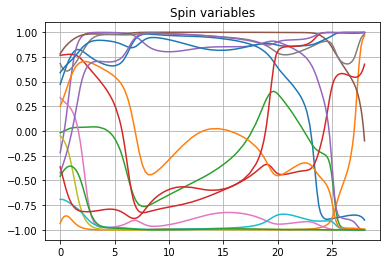

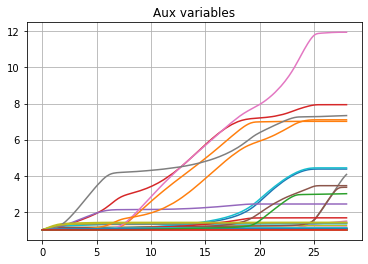

In [3]:
plot_traj(solver.sol, myProblem.number_of_variables, True)
plot_aux(solver.sol, N, True)

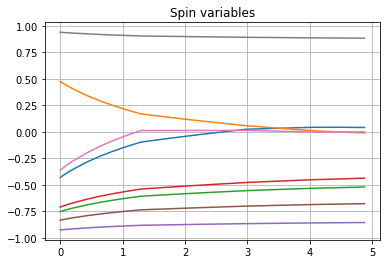

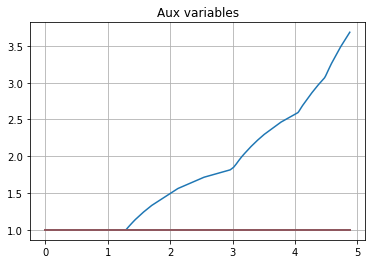

In [9]:
from pySAT import SAT, CTD, CONVERGENCE_RADIUS, HYPER_SPHERE, RHS_TYPE_POINTCHARGES, ORTANT
import numpy as np

so_file_name = 'c_libs/cSat.so'
#myProblem = SAT('SAT_problems/random3SATn15a4.266666666666667.cnf', None, rhs_type=RHS_TYPE_POINTCHARGES)
myProblem = SAT('SAT_problems/random3SATn8a4.5.cnf', None, rhs_type=RHS_TYPE_POINTCHARGES)
N, M = myProblem.number_of_variables, myProblem.number_of_clauses

init_s =  2*np.random.rand(N) - np.ones(N)

solver = CTD(myProblem, initial_s=init_s, random_aux=False)
solver.fast_solve(t_max=500, solver_type='BDF', exit_type=ORTANT)

plot_traj(solver.sol, myProblem.number_of_variables, True)
plot_aux(solver.sol, N, True)


In [3]:
solver.get_satisfied_C_of_t()

[ 0.43223034  0.43215756  0.43207345  0.43188237  0.4316908   0.4297851
  0.42789159  0.42776379  0.42767601  0.42760026  0.42748567  0.4273714
  0.42623303  0.42509912  0.42004001  0.41506565  0.41017397  0.39713923
  0.38464748  0.37264441  0.36108354  0.34649441  0.34627507  0.34609287
  0.34592188  0.34563417  0.34534699  0.34359707  0.34185626  0.33553752
  0.33523416  0.3349473   0.33466555  0.33419175  0.33371874  0.33213357
  0.33055576  0.32572971  0.32096952  0.31627453  0.30807292  0.30680147
  0.30583115  0.30486999  0.30391069  0.3029524   0.30080924  0.29867878
  0.29832779  0.29799906  0.29767721  0.29713677  0.29659733  0.29492448
  0.29325942  0.29160209  0.28612628  0.2807333   0.28009319  0.27962542
  0.27917065  0.27871498  0.27825678  0.27711532  0.2767901   0.27648983
  0.27619722  0.27571652  0.27523665  0.27386254  0.27249355  0.27112963
  0.26713534  0.26318411  0.25927486  0.25540645  0.24672428  0.23823758
  0.22993604  0.21152088  0.21101826  0.21052515  0.2

(array([0.00000000e+00, 1.52920846e-03, 3.05841691e-03, 6.46283055e-03,
        9.86724418e-03, 4.39113805e-02, 7.79555169e-02, 8.17034565e-02,
        8.54513961e-02, 8.91993358e-02, 9.49563778e-02, 1.00713420e-01,
        1.58283840e-01, 2.15854261e-01, 4.75271593e-01, 7.34688925e-01,
        9.94106258e-01, 1.70661310e+00, 2.41911994e+00, 3.13162678e+00,
        3.84413362e+00, 4.78013246e+00, 4.79941436e+00, 4.81869626e+00,
        4.83797816e+00, 4.87065205e+00, 4.90332595e+00, 5.10337919e+00,
        5.30343243e+00, 6.03769411e+00, 6.07709087e+00, 6.11648762e+00,
        6.15588437e+00, 6.22234799e+00, 6.28881161e+00, 6.51250192e+00,
        6.73619222e+00, 7.42630319e+00, 8.11641416e+00, 8.80652513e+00,
        1.00349766e+01, 1.02337755e+01, 1.03899180e+01, 1.05460604e+01,
        1.07022029e+01, 1.08583454e+01, 1.12090896e+01, 1.15598338e+01,
        1.16250569e+01, 1.16902800e+01, 1.17555031e+01, 1.18654197e+01,
        1.19753364e+01, 1.23171662e+01, 1.26589960e+01, 1.300082

## Solution planting


In [4]:
from pySAT import SAT, CTD, ORTANT
import numpy as np

so_file_name = 'c_libs/cSat.so'

k = 4
myProblem = SAT(None, so_file_name, 5, 2, planted=1, literal_number=k)
#print(myProblem.clauses)

print("Planted solution: ")
print(myProblem.planted_solutions)
print("All solutions:")
print(myProblem.all_solutions())
print("Clauses")
print(myProblem.clauses)
print("Downconverted clauses:")
myProblem.downconvert_4_3()
print(myProblem.clauses)
print("Downconverted solutions:")
print(myProblem.all_solutions())


# N, M = myProblem.number_of_variables, myProblem.number_of_clauses
# init_s =  2*np.random.rand(N) - np.ones(N)

# solver = CTD(myProblem, initial_s=init_s, random_aux=False)
# solver.fast_solve(t_max=250, solver_type='BDF', exit_type=ORTANT)

# print("Max aux:{0}".format(max(solver.sol.y[N:,-1])))
# plot_traj(solver.sol, myProblem.number_of_variables, True)
# plot_aux(solver.sol, N, True)
# myProblem.write_problem_to_file("planted"+str(k))

Planted solution: 
['11111']
All solutions:
['00000', '00001', '00100', '01000', '01001', '01010', '01100', '01101', '10110', '11000', '11100', '11101', '11111']
Clauses
[[1, -4, 5, -3], [-3, -5, 2, 4], [-3, -5, 1, -4], [-4, -2, 5, -1], [-3, -5, -4, 2], [4, 2, -1, 5], [-1, 2, -5, 3], [1, -4, 3, -5], [3, -5, -2, -1], [5, 3, 2, -4], [-4, -5, 1, -3]]
Downconverted clauses:
[[1, -4, 6], [5, -3, -6], [-3, -5, 7], [2, 4, -7], [-3, -5, 8], [1, -4, -8], [-4, -2, 9], [5, -1, -9], [-3, -5, 10], [-4, 2, -10], [4, 2, 11], [-1, 5, -11], [-1, 2, 12], [-5, 3, -12], [1, -4, 13], [3, -5, -13], [3, -5, 14], [-2, -1, -14], [5, 3, 15], [2, -4, -15], [-4, -5, 16], [1, -3, -16]]
Downconverted solutions:


In [6]:
from cProfile import label
from pySAT import SAT, CTD, ORTANT
import numpy as np
import matplotlib.pyplot as plt

so_file_name = 'c_libs/cSat.so'

n_init = 4
k = 4
lines = []
myProblem = SAT(None, so_file_name, n_init, 4.25/(2-4.25), planted=1, literal_number=k)
print(myProblem.clauses)
print("N:{0}, M:{1}, k: 4".format(myProblem.number_of_variables, myProblem.number_of_clauses))
print("Planted solution: ")
print(myProblem.planted_solutions)
print("All solutions:")
print(myProblem.all_solutions())

myProblem.downconvert_4_3()

N, M = myProblem.number_of_variables, myProblem.number_of_clauses
print("new N {0}, new M {1}, new alpha {2}".format(N, M, M/N))
init_s =  2*np.random.rand(N) - np.ones(N)
init_s[0:n_init] = myProblem.planted_solutions[0]
# solver = CTD(myProblem, initial_s=init_s, random_aux=False)
# solver.fast_solve(t_max=500, solver_type='RK45', exit_type=ORTANT)

# plot_traj(solver.sol, myProblem.number_of_variables, True)
# plot_aux(solver.sol, N, True)


[]
N:4, M:-6, k: 4
Planted solution: 
['0001']
All solutions:
['0000', '0001', '0010', '0011', '0100', '0101', '0110', '0111', '1000', '1001', '1010', '1011', '1100', '1101', '1110', '1111']
new N -2, new M -12, new alpha 6.0


ValueError: negative dimensions are not allowed

# Profiling

In [ ]:
import time
from pSAT import SAT, RK4, CTD
from matplotlib import pyplot as plt
import numpy as np
import cProfile

myProblem = SAT('chaotic_SAT/2random3SATn11c53.cnf')
mIntegrator = RK4()
solver = CTD(myProblem, mIntegrator, random_aux=True)
cProfile.run('solver.solve()', 'restats.dat')

In [10]:
import time
from pySAT import SAT as oldSAT
from pySAT_new import SAT as newSAT
import numpy as np
import cProfile

so_file_name = 'c_libs/cSat.so'

myProblem1 = oldSAT('C:\Projects\cppSAT\pySat\SAT_problems\\random3SATn60a4.9.cnf', so_file_name, rhs_type=1)
myProblem2 = newSAT('C:\Projects\cppSAT\pySat\SAT_problems\\random3SATn60a4.9.cnf', so_file_name, rhs_type=1)

N, M = myProblem1.number_of_variables, myProblem1.number_of_clauses

init_s = 2*np.random.rand(N) - np.ones(N)
init_a = np.ones(M)
init_state = np.concatenate((init_s, init_a), axis = None)
print(myProblem1.rhs(0.0, init_state)-myProblem2.rhs_new(0.0, init_state))

def test1():
    for t in range(10000):
        state = myProblem1.rhs(0.0, np.concatenate((2*np.random.rand(N) - np.ones(N), np.ones(M)), axis = None))

def test2():
    for t in range(10000):
        state = myProblem2.rhs_new(0.0, np.concatenate((2*np.random.rand(N) - np.ones(N), np.ones(M)), axis = None))

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [11]:
cProfile.run('test1()', 'restats.dat')
cProfile.run('test2()', 'restats2.dat')

In [13]:
import pstats
from pstats import SortKey
p = pstats.Stats('restats.dat')
p.strip_dirs().sort_stats(-1).print_stats()

p2 = pstats.Stats('restats2.dat')
p2.strip_dirs().sort_stats(-1).print_stats()

Wed Jan  4 15:00:18 2023    restats.dat

         260004 function calls in 44.162 seconds

   Ordered by: standard name

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
    10000    0.017    0.000    0.068    0.000 <__array_function__ internals>:2(concatenate)
    20000    0.026    0.000    0.079    0.000 <__array_function__ internals>:2(copyto)
        1    0.247    0.247   44.162   44.162 <ipython-input-10-aee8bbe90aa1>:19(test1)
        1    0.000    0.000   44.162   44.162 <string>:1(<module>)
    20000    0.082    0.000    0.082    0.000 __init__.py:514(cast)
    20000    0.048    0.000    0.048    0.000 _internal.py:249(__init__)
    20000    0.023    0.000    0.105    0.000 _internal.py:266(data_as)
    20000    0.005    0.000    0.005    0.000 multiarray.py:1054(copyto)
    10000    0.002    0.000    0.002    0.000 multiarray.py:143(concatenate)
    20000    0.037    0.000    0.169    0.000 numeric.py:148(ones)
    10000   43.359    0.004   43.569    0.0

In [ ]:
from ctypes import CDLL, POINTER, c_double, c_int
from pySAT import SAT, CTD, RHS_TYPE_THREE, RHS_TYPE_ONE, RHS_TYPE_TWO, ORTANT, CONVERGENCE_RADIUS, RHS_TYPE_FOUR
import numpy as np
import time

myProblem3 = SAT('C:\Projects\cppSAT\pySat\SAT_problems\\random3SATn20a4.35.cnf', None, rhs_type = RHS_TYPE_THREE)
cSAT_functions = CDLL('c_libs/cSAT2.so')
cSAT_functions.rhs5.restype = None
cSAT_functions.rhs3.restype = None
cSAT_functions.rhs1.restype = None
cSAT_functions.rhs2.restype = None
N, M = myProblem3.number_of_variables, myProblem3.number_of_clauses

clause_matrix = myProblem3.c.flatten().astype(np.int32) # c
clause_matrix_pointer = clause_matrix.ctypes.data_as(POINTER(c_int))

times1 = []
times2 = []
diffs = []

for i in range(10000):
    state = np.concatenate((2*np.random.rand(N)-np.ones(N), np.ones(M)))
    state = state.astype(np.double) # s & a
    state_pointer = state.ctypes.data_as(POINTER(c_double))

    result1 = np.empty(N + M)
    result1 = result1.astype(np.double) # s & a
    result1_pointer = result1.ctypes.data_as(POINTER(c_double))

    result2 = np.empty(N + M)
    result2 = result2.astype(np.double) # s & a
    result2_pointer = result2.ctypes.data_as(POINTER(c_double))

    t1 = time.time()
    cSAT_functions.rhs4(N, M, clause_matrix_pointer, state_pointer, result1_pointer)
    t2 = time.time()
    cSAT_functions.rhs5(N, M, clause_matrix_pointer, state_pointer, result2_pointer)
    t3 = time.time()

    times1.append(t2-t1)
    times2.append(t3-t2)
    diffs.append(np.linalg.norm(result1 -result2))
print('rhs4 average time: {0}'.format(sum(times1)))
print('rhs5 average time: {0}'.format(sum(times2)))
print('Average difference magnitude: {0}'.format(sum(diffs)/len(diffs)))


# Plotting

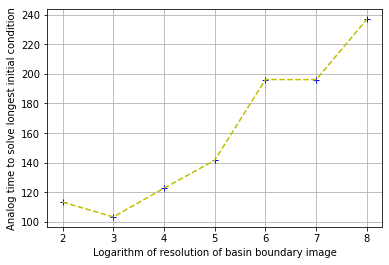

In [3]:
import numpy as np
import matplotlib.pyplot as plt

xs = list(range(2,9))
max_times = [113.39839488107091, 103.37222177560218, 122.75091766121237, 141.63069004410957, 196.16664532045627, 196.10582694555114, 236.87833199484706]
plt.grid(True)
plt.xlabel('Logarithm of resolution of basin boundary image')
plt.plot(xs, max_times, 'b+', label='times')
plt.plot(xs, max_times, 'y--', label='times')
plt.ylabel('Analog time to solve longest initial condition')
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

xs = list(range(3,9))
bbes = [0.5929533174474745, 0.7917564981137991, 0.5645170148274746, 0.5202423186763236, 0.5331399348383494, 0.5094889272364818]
plt.grid(True)
plt.xlabel('Logarithm of resolution of basin boundary image')
plt.plot(xs, bbes, label='entropies')
plt.ylabel('Basin boundary entropy of the image')
plt.legend()
plt.show()

In [12]:
# import required module
import os
import numpy as np
 
# assign directory
directory = 'results\\p'
directory2 = 'results\\p2'
directory3 = 'results\\p3'
 
# Variables to write data in
samesol = np.zeros(20)
diffsol = np.zeros(20)
samesol2 = np.zeros(20)
diffsol2 = np.zeros(20)
samesol3 = np.zeros(20)
diffsol3 = np.zeros(20)

# iterate over files in
# that directory
for filename in os.scandir(directory):
    if filename.is_file():
        with open(filename, 'r') as mahFile:
            lines = mahFile.readlines()
            for idx, line in enumerate(lines):
                if idx > 3:
                    if (int(line) > 0):
                        samesol[idx-4] += 1
                    else:
                        diffsol[idx-4] += 1

ps_n50 = [s/(s+d) for(s, d) in zip (samesol, diffsol)]
#print(ps_n50)

for filename in os.scandir(directory2):
    if filename.is_file():
        with open(filename, 'r') as mahFile:
            lines = mahFile.readlines()
            for idx, line in enumerate(lines):
                if idx > 3:
                    if (int(line) > 0):
                        samesol2[idx-4] += 1
                    else:
                        diffsol2[idx-4] += 1

ps_n45 = [s/(s+d) for(s, d) in zip (samesol2, diffsol2)]

for filename in os.scandir(directory3):
    if filename.is_file():
        with open(filename, 'r') as mahFile:
            lines = mahFile.readlines()
            for idx, line in enumerate(lines):
                if idx > 3:
                    if (int(line) > 0):
                        samesol3[idx-4] += 1
                    else:
                        diffsol3[idx-4] += 1

ps_n60 = [s/(s+d) for(s, d) in zip (samesol3, diffsol3)]

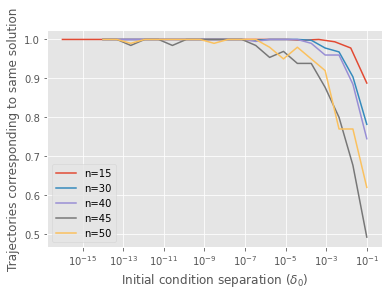

In [15]:
import matplotlib.pyplot as plt
import numpy as np

dos_n15 = [1.00000000e-16, 6.15848211e-16, 3.79269019e-15, 2.33572147e-14
, 1.43844989e-13, 8.85866790e-13, 5.45559478e-12, 3.35981829e-11
, 2.06913808e-10, 1.27427499e-09, 7.84759970e-09, 4.83293024e-08
, 2.97635144e-07, 1.83298071e-06, 1.12883789e-05, 6.95192796e-05
, 4.28133240e-04, 2.63665090e-03, 1.62377674e-02, 1.00000000e-01]
ps_n15 = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0
, 1.0, 1.0, 1.0, 0.998, 1.0, 0.994, 0.978, 0.888]

dos_n30 = [1.00000000e-14, 4.83293024e-14, 2.33572147e-13, 1.12883789e-12
, 5.45559478e-12, 2.63665090e-11, 1.27427499e-10, 6.15848211e-10
, 2.97635144e-09, 1.43844989e-08, 6.95192796e-08, 3.35981829e-07
, 1.62377674e-06, 7.84759970e-06, 3.79269019e-05, 1.83298071e-04
, 8.85866790e-04, 4.28133240e-03, 2.06913808e-02, 1.00000000e-01]
ps_n30 = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.998
, 1.0, 1.0, 1.0, 0.998, 0.978, 0.968, 0.904, 0.782]

dos_n40 = [1.00000000e-14, 4.83293024e-14, 2.33572147e-13, 1.12883789e-12
, 5.45559478e-12, 2.63665090e-11, 1.27427499e-10, 6.15848211e-10
, 2.97635144e-09, 1.43844989e-08, 6.95192796e-08, 3.35981829e-07
, 1.62377674e-06, 7.84759970e-06, 3.79269019e-05, 1.83298071e-04
, 8.85866790e-04, 4.28133240e-03, 2.06913808e-02, 1.00000000e-01]
ps_n40 = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.995
, 1.0, 1.0, 1.0, 0.99, 0.96,0.96, 0.885, 0.745]

dos_n50 = np.logspace(-14, -1, 20, endpoint=True, base=10)
dos_n45 = np.logspace(-14, -1, 20, endpoint=True, base=10)
dos_n60 = np.logspace(-14, -1, 20, endpoint=True, base=10)

with plt.style.context('ggplot'):#'seaborn-darkgrid'):
    #plt.grid(True)
    plt.xscale("log")
    plt.xlabel("Initial condition separation ($\delta_0$)")
    plt.ylabel("Trajectories corresponding to same solution")
    plt.plot(dos_n15, ps_n15, label='n=15')
    plt.plot(dos_n30, ps_n30, label='n=30')
    plt.plot(dos_n40, ps_n40, label='n=40')
    plt.plot(dos_n45, ps_n45, label='n=45')
    plt.plot(dos_n50, ps_n50, label='n=50')
    #plt.plot(dos_n60, ps_n60, label='n=60')
    plt.legend()
    #plt.show()
    plt.savefig("p_plot.png", dpi=350)

In [1]:
# import required module
import os
 
# assign directory
directory = 'results\\time_to_solution'
directory2 = 'results\\time_to_solution2'
 
# List to write data in
times_to_solutions = []
times_to_solutions2 = []

# iterate over files in
# that directory
for filename in os.scandir(directory):
    if filename.is_file():
        with open(filename, 'r') as mahFile:
            lines = mahFile.readlines()
            for idx, line in enumerate(lines):
                if idx > 2:
                    times_to_solutions.append(float(line))

for filename in os.scandir(directory2):
    if filename.is_file():
        with open(filename, 'r') as mahFile:
            lines = mahFile.readlines()
            for idx, line in enumerate(lines):
                if idx > 2:
                    times_to_solutions2.append(float(line))

In [4]:
import numpy as np
xs = np.linspace(0.0, max(times_to_solutions), 100)
ys = [sum(i > x for i in times_to_solutions) for x in xs]
ys = [y/max(ys) for y in ys]
xs2 = np.linspace(0.0, max(times_to_solutions2), 100)
ys2 = [sum(i > x for i in times_to_solutions2) for x in xs]
ys2 = [y/max(ys) for y in ys]


In [9]:
xsa = [ x for (x, y) in zip(xs, ys) if x >= 240 and x <= 440]
ysa = [ y for (x, y) in zip(xs, ys) if x >= 240 and x <= 440]
coeffs = np.polyfit(xsa, np.log(ysa), 1, w=np.sqrt(ysa))
xsb = [ x for (x, y) in zip(xs2, ys2) if x >= 240 and x <= 400]
ysb = [ y for (x, y) in zip(xs2, ys2) if x >= 240 and x <= 400]
coeffs2 = np.polyfit(xsb, np.log(ysb), 1, w=np.sqrt(ysb))
print(coeffs)
print(coeffs2)

[-0.01385013  1.13004677]
[-0.01611544  1.40847159]


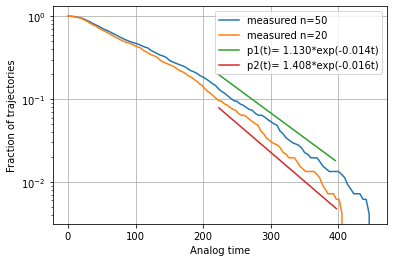

In [26]:
import matplotlib.pyplot as plt

plt.grid(True)
plt.xlabel("Analog time")
plt.ylabel("Fraction of trajectories")
plt.yscale("log")
plt.plot(xs, ys, label="measured n=50")
plt.plot(xs2, ys2, label="measured n=20")
A = "{0:.3f}".format(coeffs[1])
B = "{0:.3f}".format(coeffs[0])
C = "{0:.3f}".format(coeffs2[1])
D = "{0:.3f}".format(coeffs2[0])
plt.plot([x for x in xs if x > 220 and x < 400], [1.4*np.exp(coeffs[1]) * np.exp(coeffs[0] * x) for x in xs if x > 220 and x < 400], label="p1(t)= {0}*exp({1}t)".format(A, B))
plt.plot([x for x in xs2 if x > 220 and x < 400], [0.7*np.exp(coeffs2[1]) * np.exp(coeffs2[0] * x) for x in xs2 if x > 220 and x < 400], label="p2(t)= {0}*exp({1}t)".format(C, D))
plt.legend()
plt.savefig('escape_times_with_kappa.png', dpi=350)

In [23]:
import os
import numpy as np
 
# assign directory
directory = 'results\\kappaux'
 
# Lists to write data in
kappas = []
average_maxauxs = []


# iterate over files in
# that directory
for fidx, filename in enumerate(os.scandir(directory)):
    if filename.is_file():
        with open(filename, 'r') as mahFile:
            escape_times = np.zeros(200)
            max_auxs = np.zeros(200)
            lines = mahFile.readlines()
            for line in lines:
                if line[:3] =="idx":
                    idx = int(line.split(' ')[0].split("idx")[1][:-1])
                    if "kappa" in line:
                        escape_times[idx] = float(line.split(',')[1].replace(' ', '').replace(')', ''))
                        #escape_times[idx] = float(line.split('(')[1].split(',')[0])
                    if "maxAux" in line:
                        max_auxs[idx] = float(line.split('(')[1].split(',')[0])
            #Calculating kappa
            xs = np.linspace(0.0, max(escape_times), 99)
            ys = [sum(i > x for i in escape_times) for x in xs][:-1]
            #ys = [y/max(ys) for y in ys]
            xs = xs[:-1]
            coeffs = np.polyfit(xs, np.log(ys), 1, w=np.sqrt(ys))
            kappas.append(-coeffs[0])
            #Calculating average maxAux
            average_maxauxs.append(sum(max_auxs)/len(max_auxs))
            



maxAux = 1/(2.4096014922895543*kappa + -0.011400907238470807)


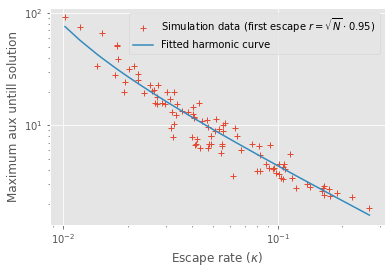

In [26]:
import matplotlib.pyplot as plt

#coeffs = np.polyfit(kappas, np.log(average_maxauxs), 1, w=np.sqrt(average_maxauxs))
coeffs2 = np.polyfit(kappas, np.reciprocal(average_maxauxs), 1, w=np.sqrt(average_maxauxs))
#print(len(kappas))
#print(len(average_maxauxs))
with plt.style.context('ggplot'):
    plt.xlabel("Escape rate ($\kappa$)")
    plt.ylabel("Maximum aux untill solution")
    plt.yscale("log")
    plt.xscale("log")
    plt.plot(kappas, average_maxauxs, '+', label='Simulation data (first escape $r=\sqrt{N} \cdot 0.95$)')
    #mahx, mahy = zip(*sorted(zip(kappas, [np.exp(coeffs[1]) * np.exp(coeffs[0] * x) for x in kappas])))
    mahx2, mahy2 = zip(*sorted(zip(kappas, [1/(coeffs2[1] + coeffs2[0] * x) for x in kappas])))
    #plt.plot(mahx, mahy, label="Fitted exponential curve")
    plt.plot(mahx2, mahy2, label="Fitted harmonic curve")
    plt.legend()
    print("maxAux = 1/({0}*kappa + {1})".format(coeffs2[0], coeffs2[1]))
    plt.savefig('kappa_maxaux.png', dpi=350)

In [21]:
import os
import numpy as np
 
# assign directory
directory = 'results\\exp_mem\\N15'
 
# Lists to write data in
trajs = []
# x axis data
lambdas = np.logspace(-5, 0.0, num=20)-0.00001

# iterate over files in
# that directory
for fidx, filename in enumerate(os.scandir(directory)):
    
    if filename.is_file():
        with open(filename, 'r') as mahFile:
            one_traj = []
            lines = mahFile.readlines()
            for idx, line in enumerate(lines):
                if idx > 1:
                    elements = [i for i in line.split(" ") if i]
                    for element in elements:
                        dummy = element.replace('[', '')
                        dummy = dummy.replace(']', '')
                        dummy = dummy.replace('\n', '')
                        try:
                            one_traj.append(float(dummy))
                        except Exception as err:
                            pass
            trajs.append(one_traj)

print([len(i) for i in trajs])

[20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20, 20]


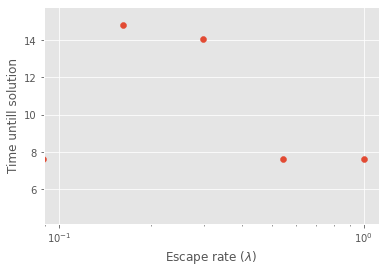

In [23]:
import matplotlib.pyplot as plt

with plt.style.context('ggplot'):
    plt.xlabel("Escape rate ($\lambda$)")
    plt.ylabel("Time untill solution")
    plt.xscale("log")
    plt.scatter(lambdas, trajs[2])


In [40]:
# x and y given as DataFrame columns
import plotly.graph_objects as go

fig = go.Figure()

for idx, traj in enumerate(trajs):
    fig.add_trace(go.Scatter(x=lambdas, y=traj, name=str(idx), mode='lines+markers'))

fig.update_xaxes(title_text=u"\u03BB", type="log")
#fig.add_scatter(x=lambdas, y=trajs[2], log_x=True)
fig.show()